In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Lambda, Add, Multiply, Concatenate
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import math

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Input, Conv2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.applications import preprocess_input
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [ ]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Using GPU
Num GPUs Available:  1


In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
disease_types = ['No Fibrosis','Portal Fibrosis','Periportal Fibrosis','Septal Fibrosis','Cirrhosis']
# data_dir = '/kaggle/input/resized-dataset256-lung-disease-raw/Resized_Dataset'
data_dir = '/content/Resized_Dataset'
train_dir = os.path.join(data_dir)
# test_dir = os.path.join(data_dir, 'test')

In [ ]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])

train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])
train.head(3)

,File,DiseaseID,Disease Type
0,No Fibrosis/a6645.jpg,0,No Fibrosis
1,No Fibrosis/h39.jpg,0,No Fibrosis
2,No Fibrosis/a197.jpg,0,No Fibrosis


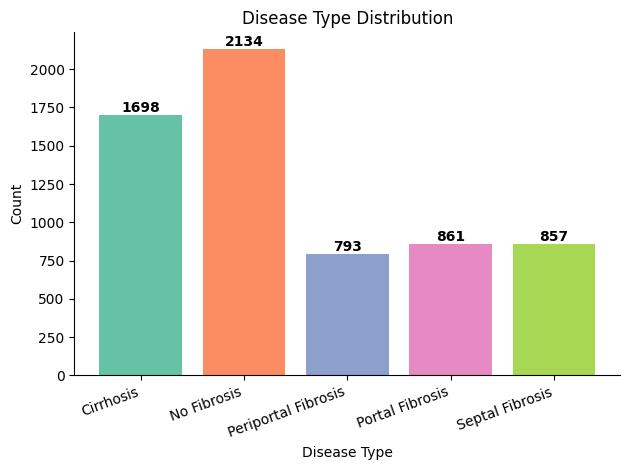

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Calculate the counts for each disease type
counts = train.groupby('Disease Type').size()

# Create the vertical bar chart
fig, ax = plt.subplots()
ax.bar(counts.index, counts, color=sns.color_palette('Set2', len(counts)))  # Use Set2 palette for soft colors

# Add labels and title
ax.set_xlabel('Disease Type')
ax.set_ylabel('Count')
ax.set_title('Disease Type Distribution')

# Annotate each bar with the count
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.2, f'{int(p.get_height())}',
            ha='center', va='bottom', color='black', fontweight='bold')

# Remove top and right spines for cleaner aesthetics
ax.spines[['top', 'right']].set_visible(False)

# Show the plot
plt.xticks(rotation=20, ha='right')  # Rotate the x-axis labels for readability
plt.tight_layout()  # Adjust layout for tight display
plt.show()

In [ ]:
# Randomize the order of training set
SEED = 42
train = train.sample(frac=1, random_state=SEED)
train.index = np.arange(len(train))
train.head(5)

,File,DiseaseID,Disease Type
0,No Fibrosis/a7025.jpg,0,No Fibrosis
1,Cirrhosis/w3543.jpg,4,Cirrhosis
2,Cirrhosis/G9968.jpg,4,Cirrhosis
3,Septal Fibrosis/ct10-55.png,3,Septal Fibrosis
4,No Fibrosis/k17.jpg,0,No Fibrosis


In [ ]:
IMAGE_SIZE = 256
SEED = 42

def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath))

In [ ]:
with tf.device('/GPU:0'):
  X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
  for i, file in tqdm(enumerate(train['File'].values)):
      image = read_image(file)
      if image is not None:
          X_train[i] = image
  X_train = X_train / 255.0

6343it [00:11, 572.16it/s]


In [ ]:
print('Train Shape: {}'.format(X_train.shape))
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=len(disease_types))

In [ ]:
SIZE = 224
N_ch = 3
SEED = 42

In [ ]:
class PhysicsInformedLayer(tf.keras.layers.Layer):
    """
    Physics-Informed Neural Network layer for ultrasound physics constraints
    """
    def __init__(self, units=128, **kwargs):
        super(PhysicsInformedLayer, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # Physics-based parameters for ultrasound wave propagation
        self.acoustic_impedance_weights = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='acoustic_impedance'
        )

        self.attenuation_weights = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='attenuation'
        )

        self.scattering_weights = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='scattering'
        )

        self.bias = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )

        super(PhysicsInformedLayer, self).build(input_shape)

    def call(self, inputs, training=None):
        # Apply physics constraints
        # Acoustic impedance modeling (tissue density changes in fibrosis)
        acoustic_component = tf.matmul(inputs, self.acoustic_impedance_weights)

        # Attenuation modeling (increased absorption in fibrotic tissue)
        attenuation_component = tf.matmul(inputs, self.attenuation_weights)
        attenuation_component = tf.nn.sigmoid(attenuation_component) * acoustic_component

        # Scattering modeling (irregular tissue structure in fibrosis)
        scattering_component = tf.matmul(inputs, self.scattering_weights)
        scattering_component = tf.nn.tanh(scattering_component)

        # Physics-informed combination
        physics_output = acoustic_component + attenuation_component * scattering_component
        physics_output = tf.nn.bias_add(physics_output, self.bias)

        return tf.nn.relu(physics_output)


In [ ]:
def ultrasound_physics_loss(y_true, y_pred):
    """
    Custom loss function incorporating ultrasound physics constraints
    """
    # Standard classification loss
    classification_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    # Physics constraint: fibrosis progression should be monotonic in severity
    # Assuming classes are ordered by severity (0: normal, 4: severe fibrosis)
    class_indices = tf.argmax(y_pred, axis=-1)
    class_indices_float = tf.cast(class_indices, tf.float32)

    # Smoothness constraint for adjacent predictions
    smoothness_penalty = tf.reduce_mean(tf.square(tf.nn.moments(class_indices_float, axes=[0])[1]))

    # Combine losses
    total_loss = classification_loss + 0.1 * smoothness_penalty

    return total_loss

In [ ]:
def build_resnet_pinn_hybrid():
    """
    Build memory-efficient hybrid ResNet50V2 + PINN model for lung fibrosis classification
    Modified to freeze all layers except last 10 layers
    """
    # Clear any existing models from memory
    tf.keras.backend.clear_session()

    tf.keras.mixed_precision.set_global_policy('mixed_float16')

    resnet = ResNet50V2(weights="imagenet",
                       include_top=False,
                       input_shape=(SIZE, SIZE, N_ch))

    for layer in resnet.layers:
        layer.trainable = False

    for layer in resnet.layers[-10:]:
        layer.trainable = True

    # Input layer
    input_layer = Input(shape=(SIZE, SIZE, N_ch))

    # Direct ResNet feature extraction (remove preprocessing layer to save memory)
    resnet_features = resnet(input_layer)

    # Reduced additional convolutional layers
    x = Conv2D(256, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.001))(resnet_features)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Smaller Physics-Informed Neural Network Branch
    physics_branch = PhysicsInformedLayer(units=128, name='physics_layer_1')(x)
    physics_branch = BatchNormalization()(physics_branch)
    physics_branch = Dropout(0.4)(physics_branch)

    # Smaller Standard Dense Branch
    dense_branch = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    dense_branch = BatchNormalization()(dense_branch)
    dense_branch = Dropout(0.5)(dense_branch)

    # Simplified feature fusion - just concatenate and reduce
    fused_features = Concatenate(axis=-1)([physics_branch, dense_branch])

    # Final classification layers
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(fused_features)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    output = Dense(5, kernel_regularizer=l2(0.01), activation='softmax',
                  name='fibrosis_classification', dtype='float32')(x)

    model = Model(input_layer, output)

    return model

In [ ]:
def create_datasets_no_augmentation(X_train, Y_train, X_val, Y_val, X_test, Y_test, batch_size=16):
    """
    Create TensorFlow datasets without data augmentation
    """
    # Training dataset without augmentation
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((X_train, Y_train))
        .shuffle(buffer_size=len(X_train))
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
        .repeat()
    )

    # Validation dataset
    val_dataset = (
        tf.data.Dataset.from_tensor_slices((X_val, Y_val))
        .batch(batch_size, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Test dataset
    test_dataset = (
        tf.data.Dataset.from_tensor_slices((X_test, Y_test))
        .batch(batch_size, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )

    return train_dataset, val_dataset, test_dataset

In [ ]:
def split_data_80_10_10(X, Y, random_state=SEED):
    """
    Split data into 80% train, 10% validation, 10% test
    """
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, Y, test_size=0.2, random_state=random_state, stratify=Y
    )

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp
    )

    return X_train, X_val, X_test, Y_train, Y_val, Y_test

In [ ]:
def train_hybrid_model(X, Y):
    """
    Memory-efficient training pipeline for ResNet50V2 + PINN hybrid model
    With 80-10-10 split and no augmentation
    """
    # Clear memory and set memory growth
    tf.keras.backend.clear_session()
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU memory setup warning: {e}")

    # Split data: 80% train, 10% val, 10% test
    X_train, X_val, X_test, Y_train, Y_val, Y_test = split_data_80_10_10(X, Y)

    print(f"Data split:")
    print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
    print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

    # Build model
    model = build_resnet_pinn_hybrid()

    # Use learning rate 0.001 with mixed precision optimizer
    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    optimizer = tf.keras.mixed_precision.LossScaleOptimizer(optimizer)

    model.compile(
        loss=ultrasound_physics_loss,
        optimizer=optimizer,
        metrics=['accuracy']
    )

    print(f"Model built successfully. Total parameters: {model.count_params():,}")

    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    lr_reducer = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=8,
        verbose=1,
        min_lr=1e-7
    )

    checkpoint = ModelCheckpoint(
        '/kaggle/working/best_resnet_pinn_hybrid.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    batch_size = 64
    train_dataset, val_dataset, test_dataset = create_datasets_no_augmentation(
        X_train, Y_train, X_val, Y_val, X_test, Y_test, batch_size
    )

    steps_per_epoch = math.ceil(len(X_train) / batch_size)
    validation_steps = math.ceil(len(X_val) / batch_size)

    # Training with 50 epochs
    EPOCHS = 50

    print("Starting training of ResNet50V2 + PINN hybrid model...")
    print(f"Steps per epoch: {steps_per_epoch}")
    print(f"Validation steps: {validation_steps}")
    print(f"Image size: {SIZE}x{SIZE}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: 0.001")
    print(f"Epochs: {EPOCHS}")
    print("Memory optimizations: Mixed precision, smaller batch size")
    print("No data augmentation applied")


    history = model.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[early_stopping, lr_reducer, checkpoint],
        validation_data=val_dataset,
        validation_steps=validation_steps,
        class_weight=None
    )

    return model, history, X_test, Y_test, test_dataset

In [ ]:
model, history, X_test, Y_test, test_dataset = train_hybrid_model(X_train, Y_train)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_curve, auc, roc_auc_score, precision_score,
                           recall_score, f1_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
import pandas as pd

# Enable unsafe deserialization for Lambda layers
keras.config.enable_unsafe_deserialization()

# Define custom PhysicsInformedLayer (you need to define this class)
# class PhysicsInformedLayer(keras.layers.Layer):
#     # Your implementation here
#     pass

# def ultrasound_physics_loss(y_true, y_pred):
#     # Your implementation here
#     pass

# Load the trained model with custom objects
custom_objects = {
    'PhysicsInformedLayer': PhysicsInformedLayer,
    'ultrasound_physics_loss': ultrasound_physics_loss
}

print("Loading model with custom objects...")
try:
    model = keras.models.load_model("/kaggle/working/best_resnet_pinn_hybrid.keras",
                                    custom_objects=custom_objects)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Trying with safe_mode=False...")
    model = keras.models.load_model("/kaggle/working/best_resnet_pinn_hybrid.keras",
                                    custom_objects=custom_objects,
                                    safe_mode=False)
    print("Model loaded successfully with safe_mode=False!")

# Print model summary
print("\nModel Architecture:")
model.summary()

def evaluate_multiclass_model(model, X_test, y_test, class_names=None, history=None):
    """
    Comprehensive multiclass model evaluation function

    Parameters:
    - model: trained Keras model
    - X_test: test features
    - y_test: test labels (categorical/one-hot encoded)
    - class_names: list of class names for labels
    - history: training history object (optional)
    """

    # Make predictions
    print("Making predictions...")
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

    # Get number of classes
    n_classes = len(np.unique(y_true))
    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]

    print(f"Number of classes: {n_classes}")
    print(f"Class names: {class_names}")

    # Create figure with subplots
    fig = plt.figure(figsize=(24, 18))

    # 1. Confusion Matrix
    plt.subplot(3, 3, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    # 2. Normalized Confusion Matrix
    plt.subplot(3, 3, 2)
    cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    # 3. Multi-class ROC Curve
    plt.subplot(3, 3, 3)

    # Binarize labels for multiclass ROC
    y_test_bin = label_binarize(y_true, classes=range(n_classes))

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(),
                                              y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], color='black', lw=2, linestyle='--',
            label=f'Micro-avg (AUC = {roc_auc["micro"]:.3f})')

    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    plt.plot(fpr["macro"], tpr["macro"], color='red', lw=2, linestyle=':',
            label=f'Macro-avg (AUC = {roc_auc["macro"]:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(True, alpha=0.3)

    # 4. Per-Class Performance Metrics Bar Chart
    plt.subplot(3, 3, 4)

    precision = precision_score(y_true, y_pred, average=None)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average=None)

    x_pos = np.arange(len(class_names))
    width = 0.25

    plt.bar(x_pos - width, precision, width, label='Precision', alpha=0.8, color='skyblue')
    plt.bar(x_pos, recall, width, label='Recall', alpha=0.8, color='lightgreen')
    plt.bar(x_pos + width, f1, width, label='F1-Score', alpha=0.8, color='salmon')

    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.xticks(x_pos, class_names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)

    # 5. Class Distribution
    plt.subplot(3, 3, 5)
    unique, counts = np.unique(y_true, return_counts=True)
    colors_dist = plt.cm.Set3(np.linspace(0, 1, len(unique)))
    plt.pie(counts, labels=[class_names[i] for i in unique], autopct='%1.1f%%',
            colors=colors_dist, startangle=90)
    plt.title('True Class Distribution', fontsize=14, fontweight='bold')

    # 6. Prediction Confidence Distribution
    plt.subplot(3, 3, 6)
    max_probs = np.max(y_pred_proba, axis=1)
    plt.hist(max_probs, bins=30, alpha=0.7, color='purple', edgecolor='black')
    plt.xlabel('Maximum Prediction Probability')
    plt.ylabel('Frequency')
    plt.title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axvline(np.mean(max_probs), color='red', linestyle='--',
                label=f'Mean: {np.mean(max_probs):.3f}')
    plt.legend()

    # 7-8. Training History (if provided)
    if history is not None:
        # Loss plot
        plt.subplot(3, 3, 7)
        plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
        plt.title('Model Loss', fontsize=14, fontweight='bold')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Accuracy plot
        plt.subplot(3, 3, 8)
        acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
        val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

        if acc_key in history.history:
            plt.plot(history.history[acc_key], label='Training Accuracy', linewidth=2, color='blue')
        if val_acc_key in history.history:
            plt.plot(history.history[val_acc_key], label='Validation Accuracy', linewidth=2, color='red')

        plt.title('Model Accuracy', fontsize=14, fontweight='bold')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True, alpha=0.3)

    # 9. Top Misclassifications
    plt.subplot(3, 3, 9)
    misclassified = y_true != y_pred
    if np.sum(misclassified) > 0:
        misclass_true = y_true[misclassified]
        misclass_pred = y_pred[misclassified]

        # Create confusion pairs
        misclass_pairs = [(misclass_true[i], misclass_pred[i]) for i in range(len(misclass_true))]
        unique_pairs, pair_counts = np.unique(misclass_pairs, axis=0, return_counts=True)

        # Sort by frequency
        sorted_indices = np.argsort(pair_counts)[::-1]
        top_pairs = unique_pairs[sorted_indices[:10]]  # Top 10 misclassifications
        top_counts = pair_counts[sorted_indices[:10]]

        labels = [f'{class_names[pair[0]]}→{class_names[pair[1]]}' for pair in top_pairs]

        plt.barh(range(len(top_pairs)), top_counts, color='coral')
        plt.yticks(range(len(top_pairs)), labels)
        plt.xlabel('Count')
        plt.title('Top Misclassifications', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Perfect Classification!\nNo Misclassifications',
                ha='center', va='center', fontsize=12, fontweight='bold')
        plt.xlim(0, 1)
        plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Print detailed classification report
    print("\n" + "="*70)
    print("DETAILED MULTICLASS CLASSIFICATION REPORT")
    print("="*70)

    # Overall accuracy
    accuracy = np.mean(y_pred == y_true)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Classification report
    print(f"\nDetailed Classification Report:")
    print("-" * 50)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # ROC AUC Scores
    try:
        roc_auc_ovr = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
        roc_auc_ovo = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', average='macro')
        print(f"ROC AUC Score (One-vs-Rest): {roc_auc_ovr:.4f}")
        print(f"ROC AUC Score (One-vs-One): {roc_auc_ovo:.4f}")
    except Exception as e:
        print(f"Error calculating ROC AUC: {e}")
        roc_auc_ovr = roc_auc["macro"]

    # Average metrics
    avg_precision = np.mean(precision)
    avg_recall = np.mean(recall)
    avg_f1 = np.mean(f1)

    print(f"\nAverage Metrics:")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Average Recall: {avg_recall:.4f}")
    print(f"Average F1-Score: {avg_f1:.4f}")

    # Per-class metrics summary
    print(f"\nPer-Class Metrics Summary:")
    print("-" * 50)
    for i, class_name in enumerate(class_names):
        print(f"{class_name}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall: {recall[i]:.4f}")
        print(f"  F1-Score: {f1[i]:.4f}")
        print(f"  ROC AUC: {roc_auc[i]:.4f}")
        print(f"  Support: {np.sum(y_true == i)}")
        print()

    # Model confidence statistics
    print(f"Prediction Confidence Statistics:")
    print(f"Mean confidence: {np.mean(max_probs):.4f}")
    print(f"Std confidence: {np.std(max_probs):.4f}")
    print(f"Min confidence: {np.min(max_probs):.4f}")
    print(f"Max confidence: {np.max(max_probs):.4f}")

    return {
        'accuracy': accuracy,
        'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True),
        'confusion_matrix': cm,
        'normalized_confusion_matrix': cm_normalized,
        'predictions': y_pred,
        'predicted_probabilities': y_pred_proba,
        'true_labels': y_true,
        'roc_auc_ovr': roc_auc_ovr if 'roc_auc_ovr' in locals() else roc_auc["macro"],
        'per_class_metrics': {
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': [roc_auc[i] for i in range(n_classes)]
        },
        'confidence_stats': {
            'mean': np.mean(max_probs),
            'std': np.std(max_probs),
            'min': np.min(max_probs),
            'max': np.max(max_probs)
        }
    }

# Example usage:
print("\n" + "="*50)
print("EVALUATING MODEL PERFORMANCE")
print("="*50)

# Make sure you have these variables defined:
# X_val, Y_val, disease_types, history


results = evaluate_multiclass_model(
    model=model,
    X_test=X_val,
    y_test=Y_val,
    class_names=disease_types,
    history=history
)

# Access individual results
print("\n" + "="*30)
print("FINAL RESULTS SUMMARY")
print("="*30)
print(f"Overall Accuracy: {results['accuracy']:.4f}")
print(f"Overall ROC AUC: {results['roc_auc_ovr']:.4f}")
print(f"Average Precision: {np.mean(results['per_class_metrics']['precision']):.4f}")
print(f"Average Recall: {np.mean(results['per_class_metrics']['recall']):.4f}")
print(f"Average F1-Score: {np.mean(results['per_class_metrics']['f1_score']):.4f}")